In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mini-Lab: Seaborn objects interface

In this mini lab you are going to learn seaborns new **objects** interface. For a decade, seaborn has provided better defaults, ready-built plot types and a higher-level API to the Python plotting environment. It is now experimenting with a very different interface: the [objects](https://seaborn.pydata.org/api.html#objects-interface) interface. Inspired by R's "ggplot2", it allows the user to iteratively map data to aesthetics through a series of layers, treating plots as a singule unit of interconnected aesthetics rather than piles of visual elements. 

The package itself is only a couple years old, is still somewhat experimental, and is missing a number of eventual features (there are some plot types that must be made with the standard function interface). However, it is a good idea to develop a familiarity with this new API since it will likely grow rapidly in popularity in the following years as its functionality is fleshed out. "ggplot2" eventually became the default plotting framework for R users and I expect a similar trend in seaborns objects interface.

In this lab, we'll be visualizing some data about car insurance premiums.

In [128]:
# Read the data
ins = pd.read_csv("./data/car_insurance_premium_dataset.csv")
# Create a new variable indicating whether the driver has had an accident or not
ins["past_accident"] = np.where(ins["Previous Accidents"] > 0, "yes", "no")
ins.head()

,Driver Age,Driver Experience,Previous Accidents,Annual Mileage (x1000 km),Car Manufacturing Year,Car Age,Insurance Premium,past_accident
0,56,32,4,17,2002,23,488.35,yes
1,46,19,0,21,2025,0,486.15,no
2,32,11,4,15,2020,5,497.55,yes
3,60,0,4,19,1991,34,498.35,yes
4,25,7,0,13,2005,20,495.55,no


Seaborns base functionality is identical to matplotlibs `pyplot` interface. Using a specific chart type such as `relplot`, plot data with various arguments that pass implicit labels and artists. You can then use matplotlib functions to further edit the figure.

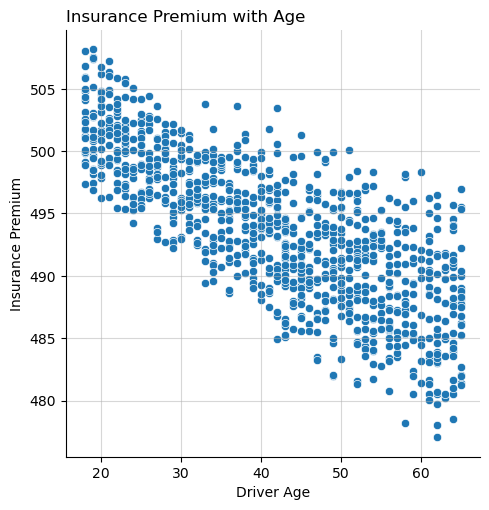

In [129]:
sns.relplot(data = ins, x = "Driver Age", y = "Insurance Premium")
plt.title("Insurance Premium with Age", loc = "left")
plt.grid(alpha = 0.5)

Using different bespoke seaborn chart types will plot different types of associations holistically for us.

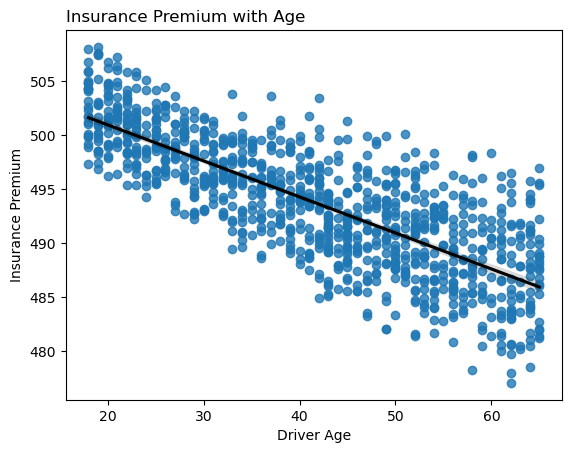

In [130]:
sns.regplot(data = ins, x = "Driver Age", y = "Insurance Premium", line_kws = {"color": "black"})
plt.title("Insurance Premium with Age", loc = "left");

This is a great way to make all sorts of figures and I expect you will use seaborn in the standard fashion for many of your plotting assingments. However, we will now explore seaborns "objects" interface. 

### Seaborn objects

The logic behind the objects interface is simple: instatiate a plot with some dataset and basic visual elements (axis labels, grid lines etc...), then iteratively add layers of visualization to this plot with `.add()`.

#### 1. A basic plot

We will create a scatterplot of Insurance Premium as a function of Driver Age and tweak some visual elements.

Create the plot with no added layers yet using [so.Plot](https://seaborn.pydata.org/generated/seaborn.objects.Plot.html). You will pass the usual seaborn arguments (data, x and y), but don't `.add()` a layer yet. You should see an Axes with no visual artists.

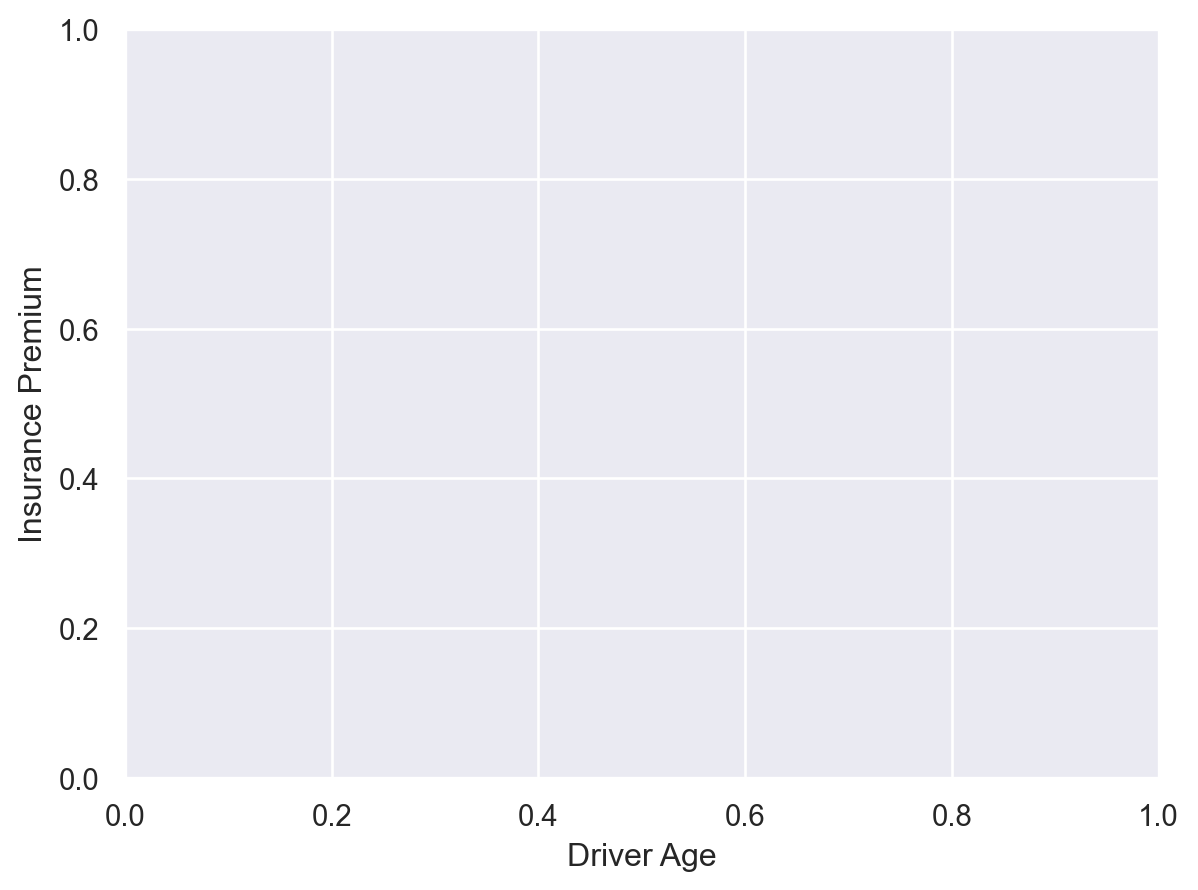

In [131]:
import seaborn.objects as so

so.Plot(data = ins, x = "Driver Age", y = "Insurance Premium")

Now add a layer with `.add()`, passing the desired "Mark" as an argument. The mark we want for a scatterplot is `so.Dot()`. Reference the [documentation](https://seaborn.pydata.org/generated/seaborn.objects.Plot.add.html) if you're uncertain how to do this. 

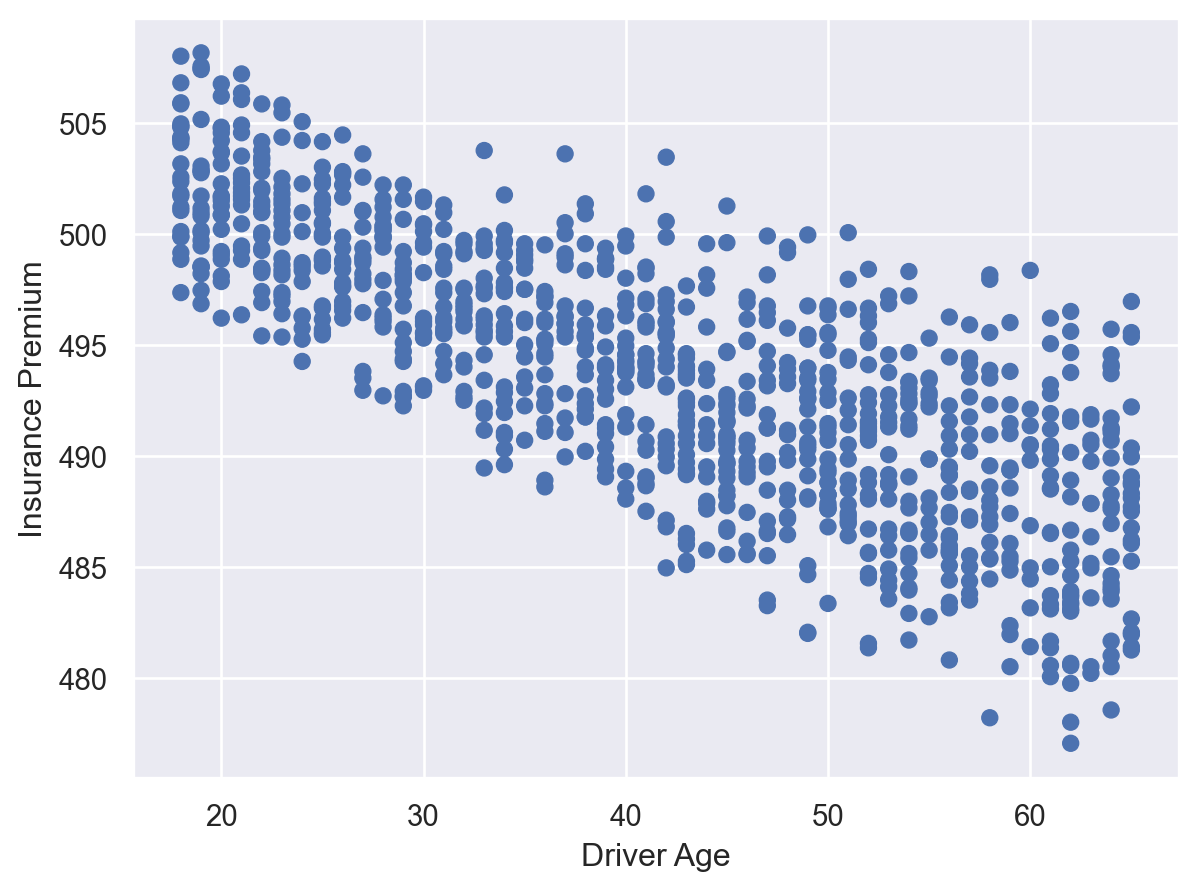

In [132]:
## Add a Dot layer to the Plot

so.Plot(data = ins, x = "Driver Age", y = "Insurance Premium").add(so.Dot())

It starts out as simple as that. There a range of marks to choose from at the moment, the most important being `so.Dot()`, `so.Line()` and `so.Bar()`. Check out the full [list of objects methods](https://seaborn.pydata.org/generated/seaborn.objects.Dot.html) for the types of marks available, as well as the [mark properties](https://seaborn.pydata.org/tutorial/properties.html) that can be modified. 

#### 2. Edit visual styling

The `objects` interface lets you edit aesthetic properties in a hierarchical manner. Any aesthetics passed in `Plot()` will be inherited by all subsequent layers; aesthetics passed in `add()` will be inherited by all marks in a layer, and aesthetics passed to a mark will only apply to those marks.

First, change the color of your points to something other than the default and change the marker types to squares ('s') via the arguments in `so.Dot()`.

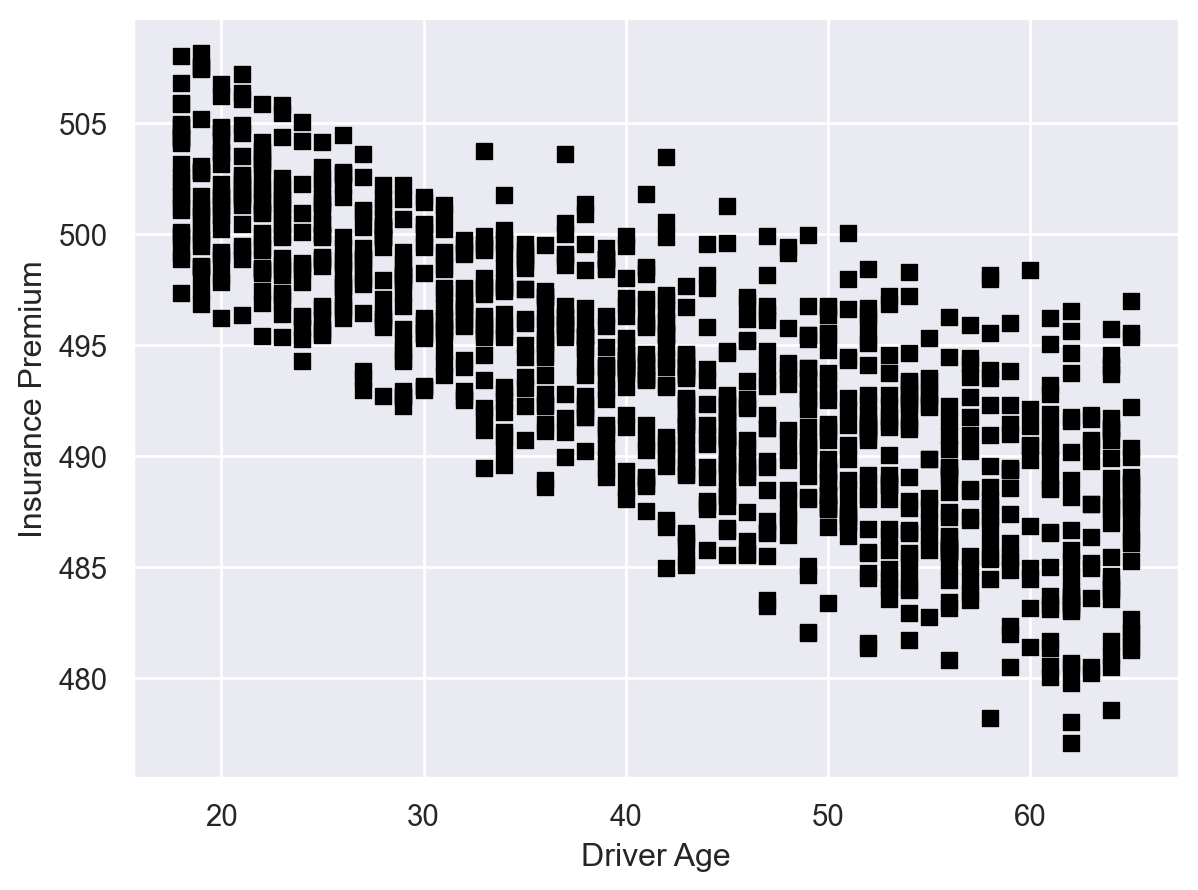

In [133]:
## Change color and marker in the Dot mark

so.Plot(data = ins, x = "Driver Age", y = "Insurance Premium").add(so.Dot(color = "black", marker = "s"))

Now let's add a smooth line to the plot. The association looks close to linear but a non-linear line might best represent it. Marks can be moved (called a "Move") or transformed (called a "Transform").

Add another layer to the plot with `so.Line` as a mark, and then transform it with the transform `so.PolyFit()`. This transformation will change the line to be a best-fit polynomial. You can do this by providing both the mark and transform as arguments to `.add()`. Try adding the `Line` mark first without the transform and then with the transform to see how the transformation is changing the figure.

Make the line a color different from your points and increase its linewidth.

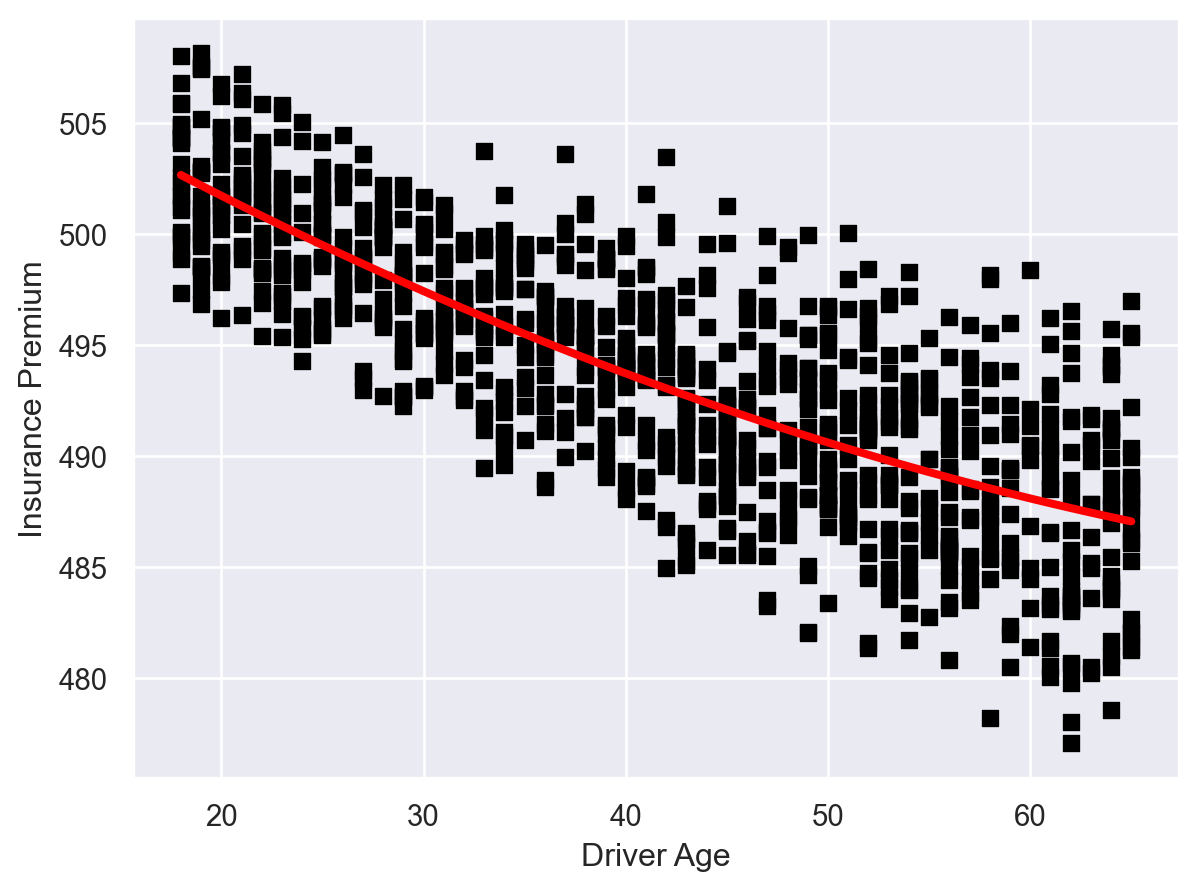

In [134]:
##

so.Plot(
    data = ins, x = "Driver Age", y = "Insurance Premium").add(
    so.Dot(marker = "s", color = "black")).add(so.Line(color = "red", linewidth = 3), so.PolyFit())

To observe how the general trend differs when past accidents are considered, we could also add two fit lines to each group ("yes" or "no") as well (`group = "past_accident` in `so.Plot`). Alternatively, a nice feature the objects interface brings to our plotting environment is "faceting". This is an automated subplot feature where we can convert a plot with many levels of a group into small multiples. Note that unlike `plt.subplots`, faceting will keep the same x- and y-axis ranges by default. 

Use `facet("past_accident")` to facet the plots. Like any method associated with the objects interface, this function is applied to your entire plot object.

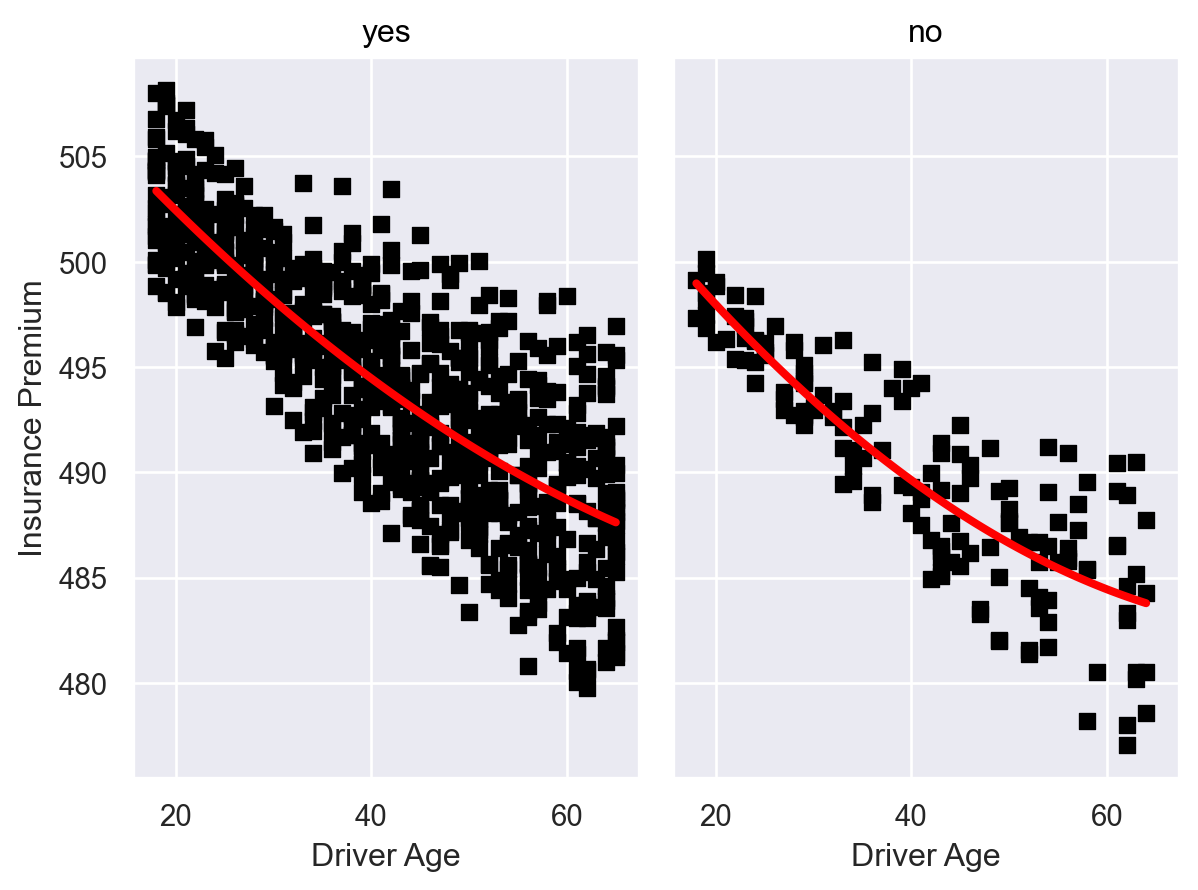

In [135]:
## Facet the plot by past_accident

p = so.Plot(
    data = ins, x = "Driver Age", y = "Insurance Premium").add(
    so.Dot(marker = "s", color = "black")).add(
    so.Line(color = "red", linewidth = 3), so.PolyFit()).facet(
    "past_accident")

p

Going back to just the scatterplot, can could also compare the difference in trends by mapping mark qualities to other variables in our data. In `Plot()`, change the `color` based on past_accident and change `pointsize` by Annual Mileage. You don't need to add the Line layer or facet the plot. 

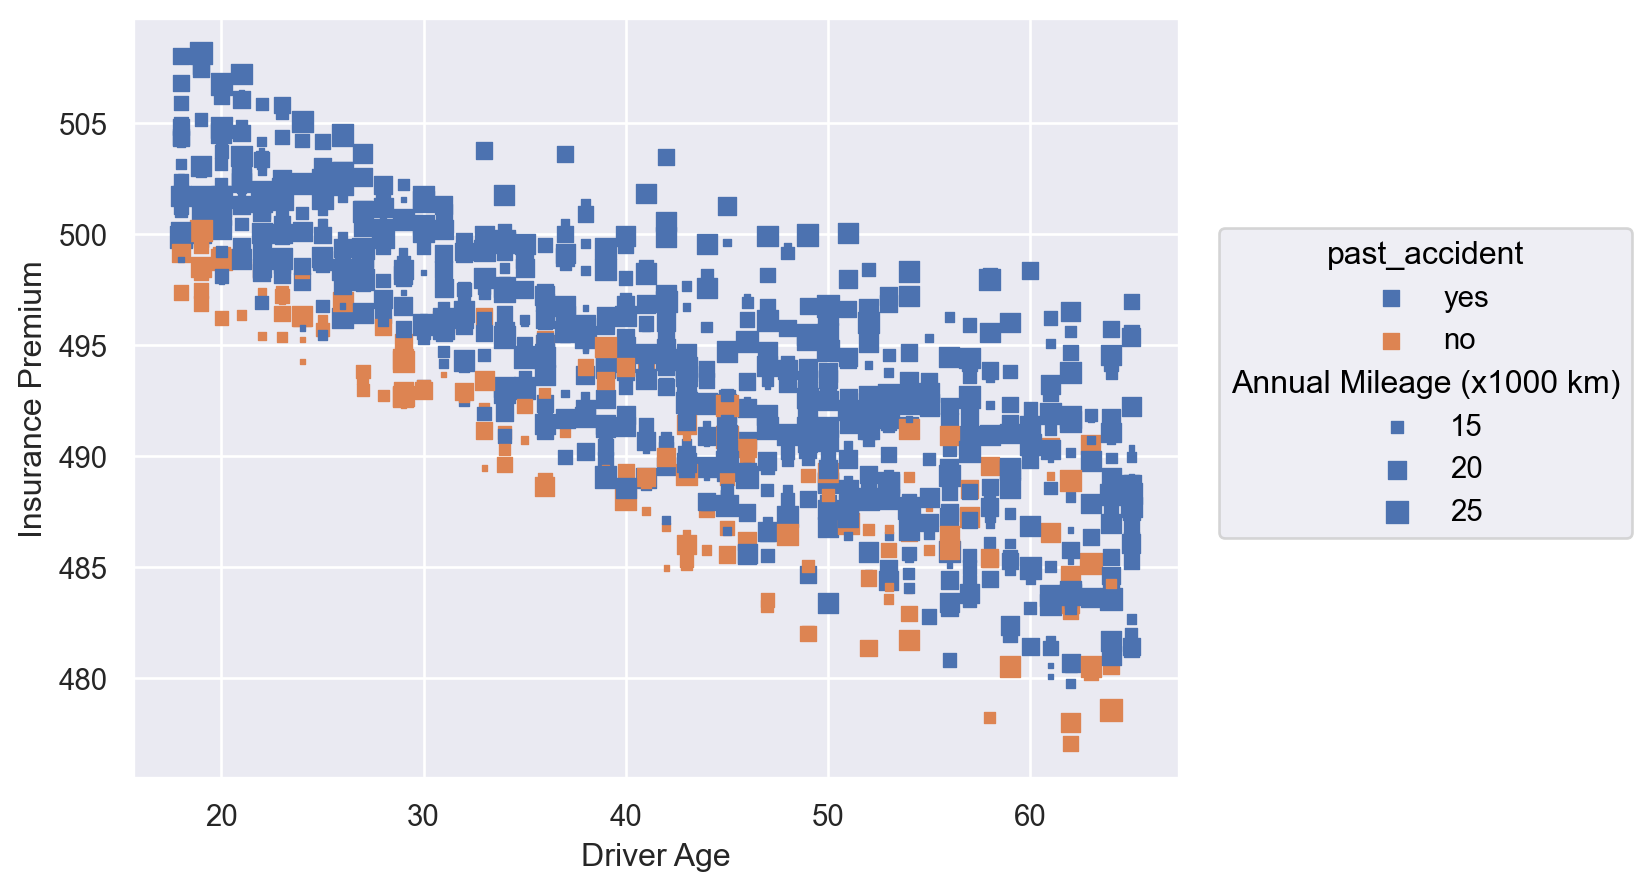

In [136]:
## Change color by past_accident and pointsize by Annual Mileage in Plot


p = so.Plot(
    data = ins, x = "Driver Age", y = "Insurance Premium", color = "past_accident", pointsize = "Annual Mileage (x1000 km)").add(
    so.Dot(marker = "s"))

p

You can change the color palette used iny our graphs with `.scale(color = palette)` at the end of your plotting function. First recreate your plot and assign it equal to `p`. Then apply your new palette with `p.scale()`

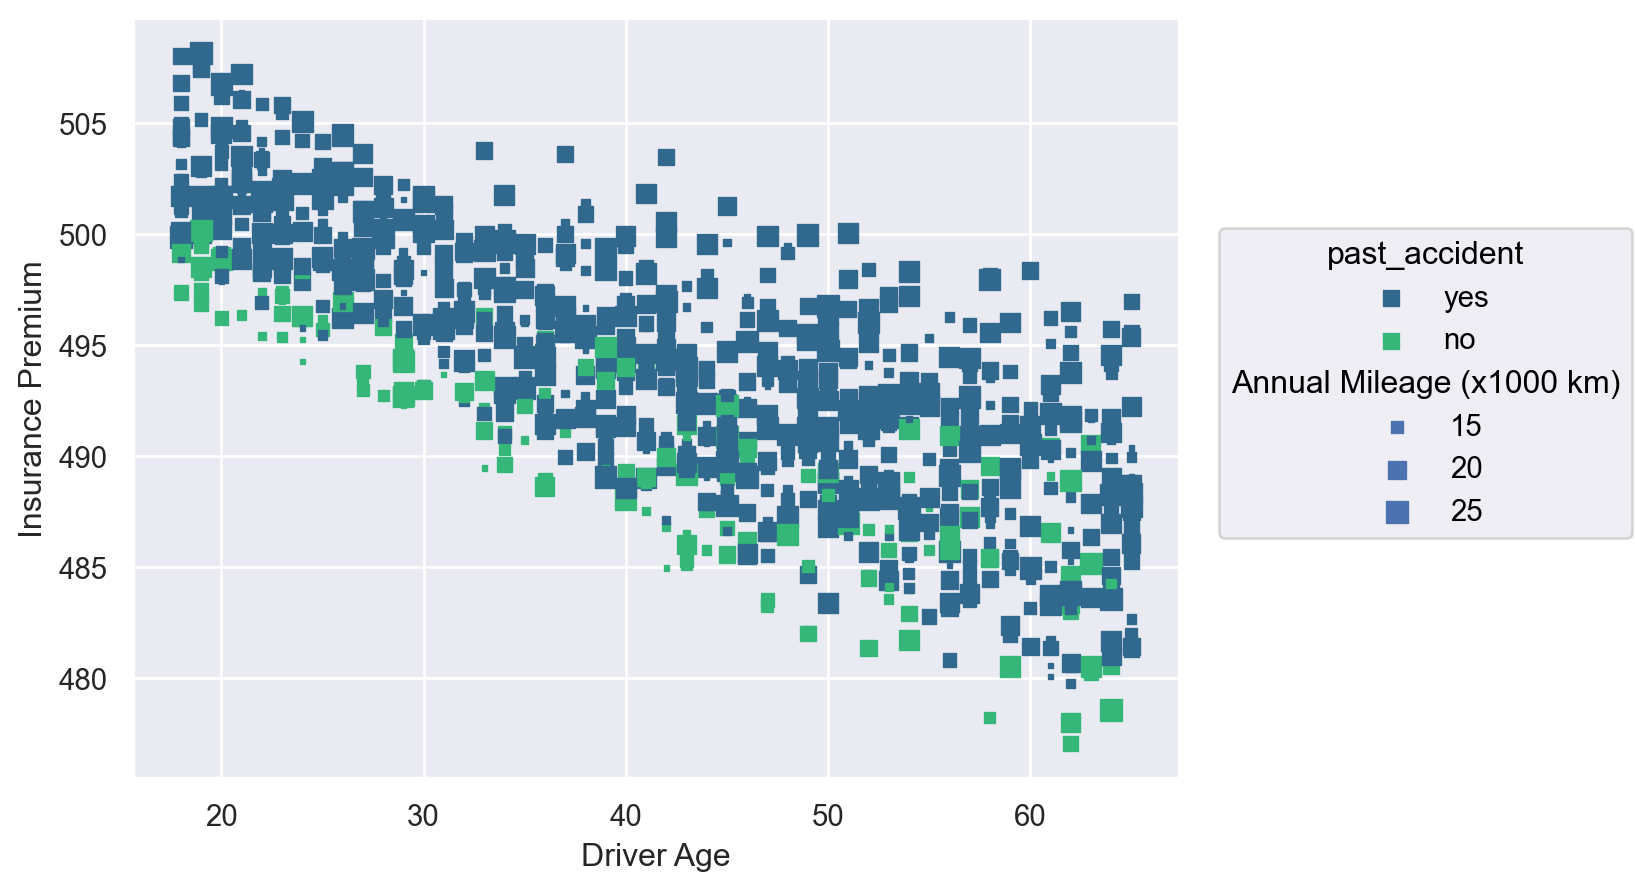

In [137]:
## Use scale to change the palette of the plot

p = so.Plot(
    data = ins, x = "Driver Age", y = "Insurance Premium", color = "past_accident", pointsize = "Annual Mileage (x1000 km)").add(
    so.Dot(marker = "s"))

p = p.scale(color = "viridis")
p

#### 3. Category plots

Create a barplot with `Bar()` of Insurance Premiums based on whether the driver has had a past accident or not.

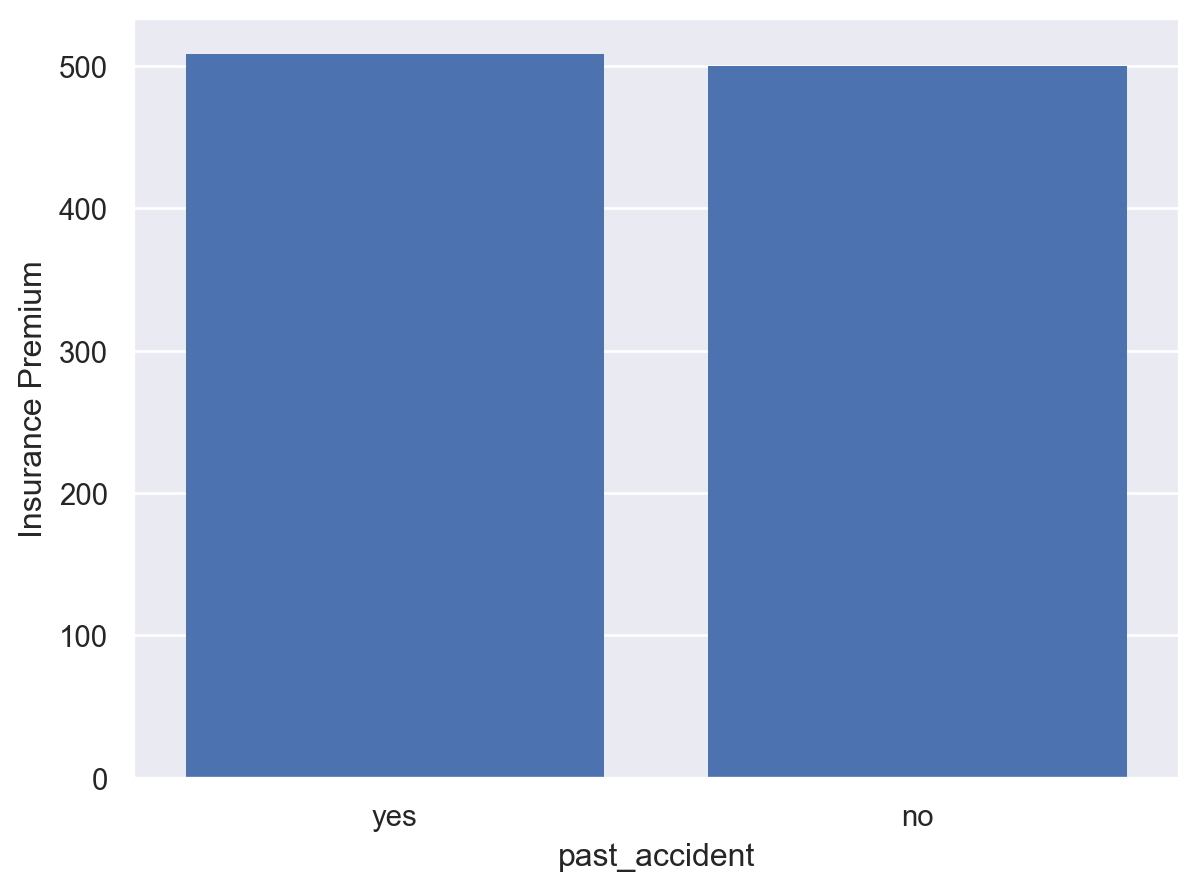

In [138]:
## Create a Bar layer
b = so.Plot(data = ins, x = "past_accident", y = "Insurance Premium").add(so.Bar())

b

Note that the barplot was automatically created of the mean. If we wanted to, we could instead look at the medians (or any other statistic) by applying a transform to the bar. Use the transform [Agg](https://seaborn.pydata.org/generated/seaborn.objects.Agg.html) to make a barplots of the median instead. Use [limit](https://seaborn.pydata.org/generated/seaborn.objects.Plot.limit.html#seaborn.objects.Plot.limit) to change the range of the y-axis so differences can be more clearly seen (consider how this changes your interpretation of the figure). 

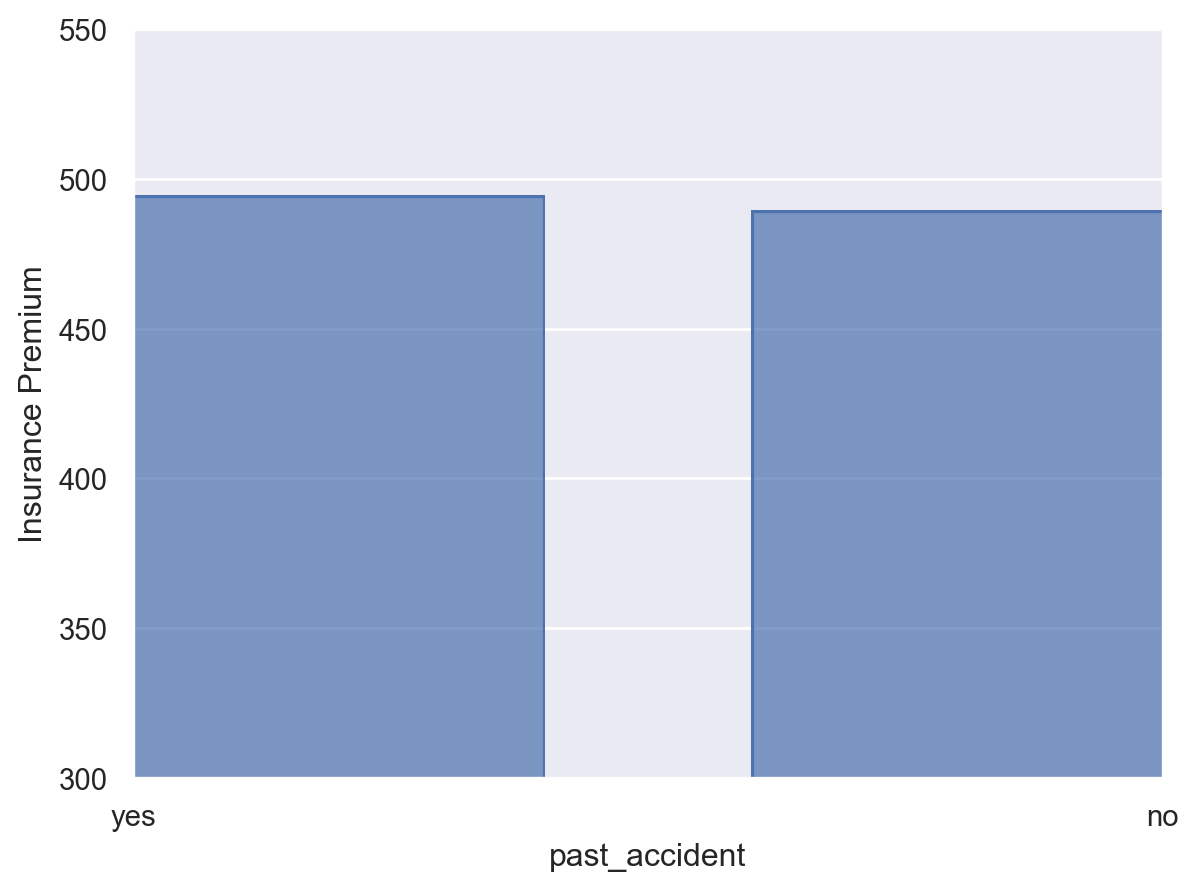

In [139]:
## Replot the Bar using median as the aggregation function instead, and constrain the y axis range to zoom in on the difference

b = so.Plot(data = ins, x = "past_accident", y = "Insurance Premium").add(so.Bar(), so.Agg("median")).limit(x = (0, 1), y = (300, 550))

b

This representing a summary statistic of a sample, we should have either a standard deviation or confidence interval. Use [Range](https://seaborn.pydata.org/generated/seaborn.objects.Range.html) with [Est](https://seaborn.pydata.org/generated/seaborn.objects.Est.html) to add sd or error bars.

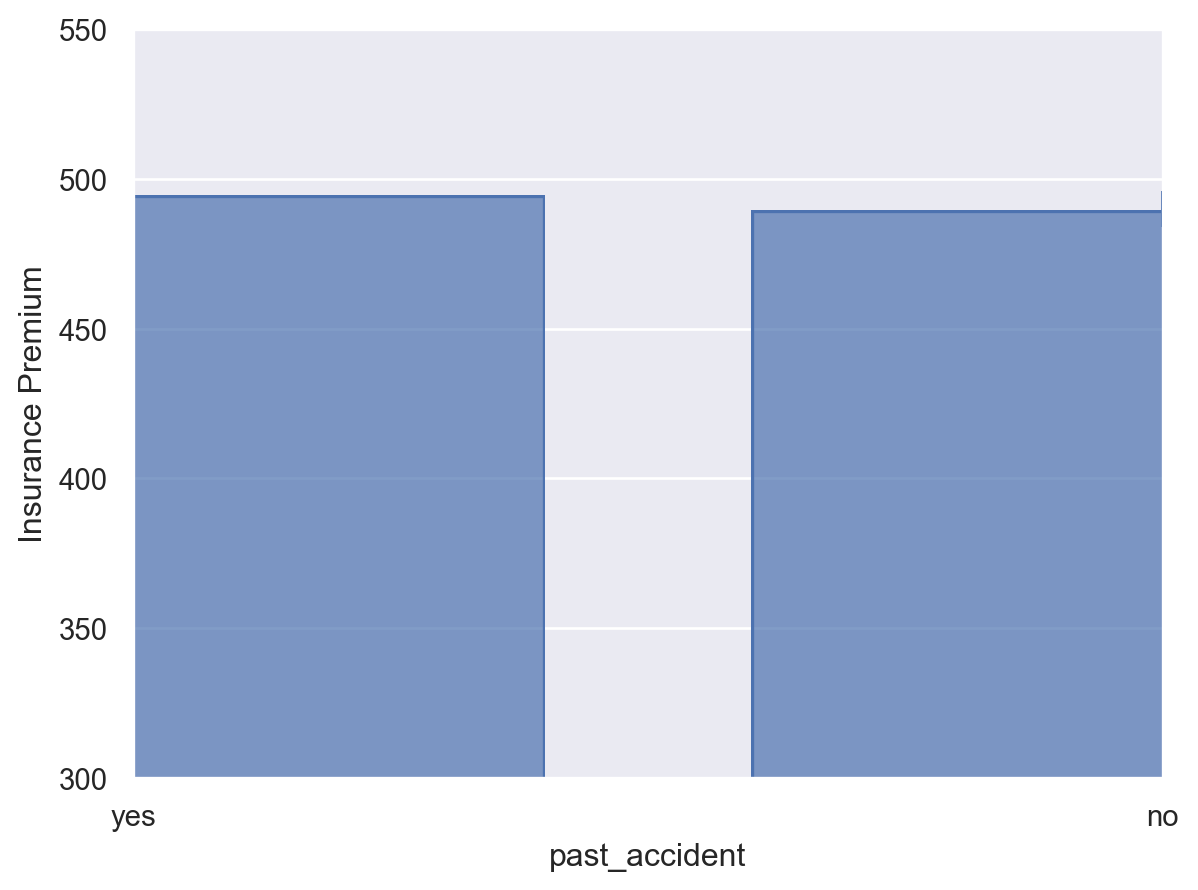

In [140]:
## Add error or standard deviation bars
b = so.Plot(data = ins, x = "past_accident", y = "Insurance Premium").add(
    so.Bar(), so.Agg("median")).limit(
    x = (0, 1), y = (300, 550)).add(so.Range(), so.Est(errorbar = "sd"))

b


That's it for this lab. As usual, there's quite a bit more you can do with the objects interface (refer to the objects API. However, the package is very young and it can't be relied on to do everything you'd like to. Use it where it seems useful or don't use it all. However, this "grammar of graphics" approach to statistical plotting is increasing in relevance and it should stay on your radar.

Please submit this notebook or your script to the relevant assignment on Canvas. 